In [ ]:
from google.colab import files
import os
import pandas as pd

uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d henriqueyamahata/bank-marketing -p /content
!unzip -q /content/bank-marketing.zip -d /content/bank_marketing

df = pd.read_csv('/content/bank_marketing/bank-additional-full.csv', sep=';')
df.head()


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing
License(s): other
  0% 0.00/393k [00:00<?, ?B/s]
100% 393k/393k [00:00<00:00, 843MB/s]


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**Basic Info and Class Distribution**

In [ ]:
df.info()
df['y'].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,proportion
y,
no,0.887346
yes,0.112654


Feature and Target Split

In [ ]:
X = df.drop(columns=['y'])
y = df['y'].map({'yes':1,'no':0})


Identify Categorical and Numerical Columns

In [ ]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols, cat_cols


(['age',
  'duration',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'])

Preprocessing Pipelines

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Preprocessing and SMOTE Balancing

In [ ]:
from imblearn.over_sampling import SMOTE

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_proc, y_train)


ML Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVC': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


Train Models

In [ ]:
trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:20:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluate Models

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_proc)
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC': roc
    })

results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.920612,0.654279,0.626078,0.639868,0.951473
1,RandomForest,0.915513,0.630926,0.602371,0.616318,0.948061
2,LogisticRegression,0.869993,0.460908,0.908405,0.611534,0.943505
3,SVC,0.870478,0.461195,0.890086,0.607576,0.942075
4,KNN,0.851299,0.418362,0.820043,0.554059,0.884111
5,DecisionTree,0.886380,0.496310,0.579741,0.534791,0.752525


Model Comparison Visualization

/tmp/ipython-input-3210578909.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3210578909.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3210578909.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3210578909.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3210578909.py

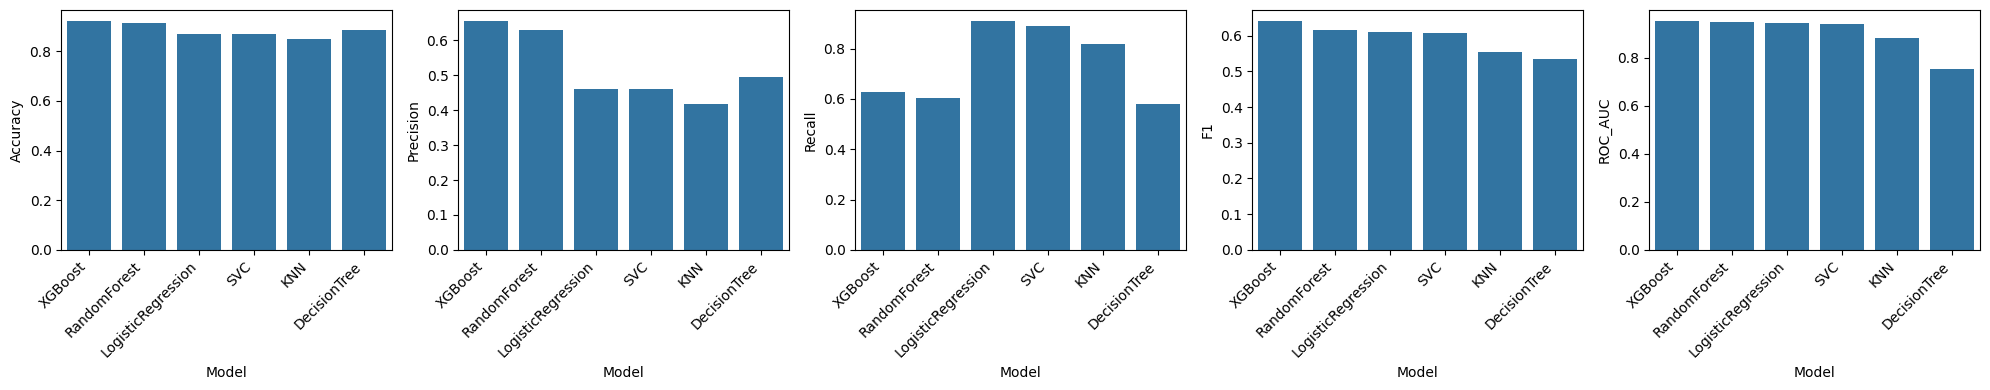

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 4))

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=results_df, ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


ROC Curves

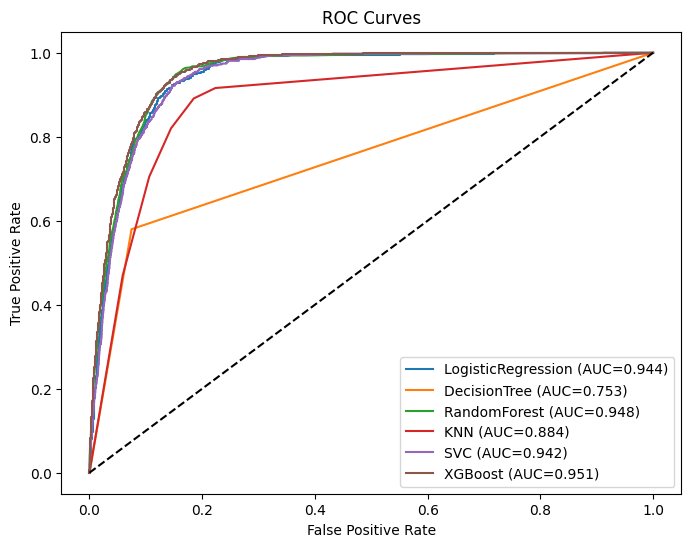

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()


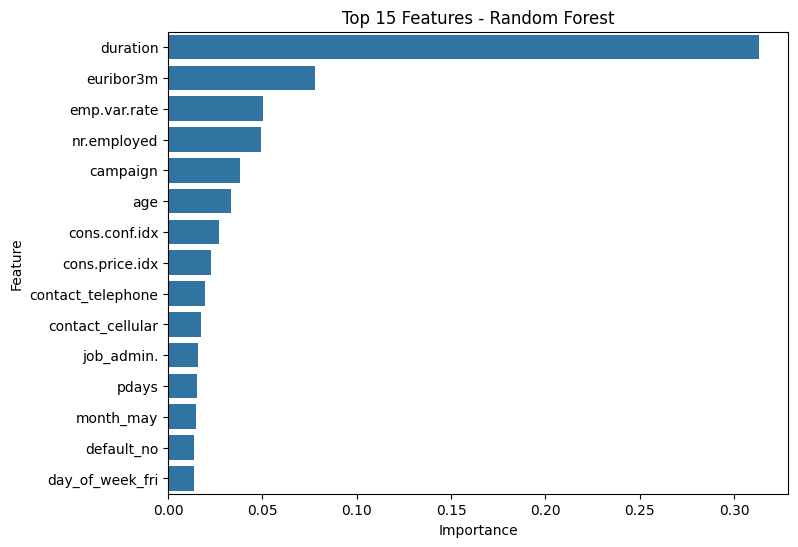

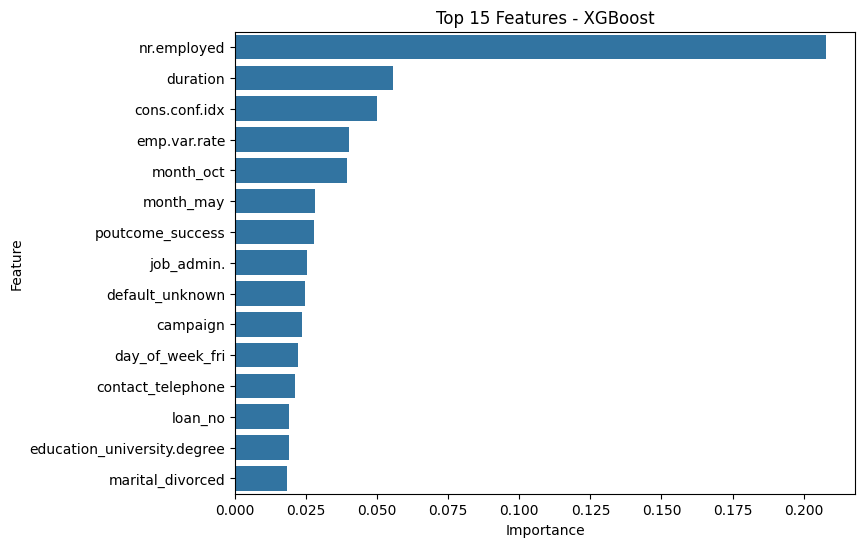

In [ ]:
def get_feature_names(preprocessor):
    num_features = num_cols
    cat_features = list(preprocessor.named_transformers_['cat']
                        .named_steps['onehot']
                        .get_feature_names_out(cat_cols))
    return num_features + cat_features

feature_names = get_feature_names(preprocessor)

if 'RandomForest' in trained_models:
    rf = trained_models['RandomForest']
    imp = pd.DataFrame({'Feature': feature_names,
                        'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False).head(15)
    plt.figure(figsize=(8,6))
    sns.barplot(y='Feature', x='Importance', data=imp)
    plt.title('Top 15 Features - Random Forest')
    plt.show()

if 'XGBoost' in trained_models:
    xgb = trained_models['XGBoost']
    imp_x = pd.DataFrame({'Feature': feature_names,
                          'Importance': xgb.feature_importances_}).sort_values('Importance', ascending=False).head(15)
    plt.figure(figsize=(8,6))
    sns.barplot(y='Feature', x='Importance', data=imp_x)
    plt.title('Top 15 Features - XGBoost')
    plt.show()
